In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop('math_score', axis = 1)
y = df['math_score']

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

<h3>Data Preprocessing</h3>

In [10]:
le = LabelEncoder()
st = StandardScaler()
for i in X.columns:
    if X[i].dtype == 'object':
        X[i] = le.fit_transform(X[i])
    else:
        X[i] = st.fit_transform(X[i].values.reshape(-1, 1))

In [11]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,-0.964625,-1.015044,-0.812640,0.741881,0.746748,0.193999,0.391492
1,-0.964625,-0.150441,0.827953,0.741881,-1.339140,1.427476,1.313269
2,-0.964625,-1.015044,0.281088,0.741881,0.746748,1.770109,1.642475
3,1.036672,-1.879647,-1.359505,-1.347925,0.746748,-0.833899,-1.583744
4,1.036672,-0.150441,0.827953,0.741881,0.746748,0.605158,0.457333


In [13]:
X.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
reading_score                  72
writing_score                  77
dtype: int64

In [14]:
X['gender'].value_counts()

gender
-0.964625    518
 1.036672    482
Name: count, dtype: int64

<h3>Splitting the Data for training and testing</h3>

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 10)

In [27]:
def model_accuracy(x,y):
    print('R2 Score : ', r2_score(x,y));
    print('MAE : ', mean_absolute_error(x,y));
    print('MSE : ', mean_squared_error(x,y));
    print('RMSE : ', np.sqrt(mean_squared_error(x,y)));

In [29]:
models = {   
    'Linear Regression' : LinearRegression(),
    'Ridge Regression' : Ridge(),
    'Lasso Regression' : Lasso(),
    'Decision Tree Regressor' : DecisionTreeRegressor(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'AdaBoost Regressor' : AdaBoostRegressor(),
    'KNN Regressor' : KNeighborsRegressor(),
    'SVR' : SVR(),
    'CatBoost Regressor' : CatBoostRegressor(verbose = 0),
    'XGB Regressor' : XGBRegressor()
}

for model in models.values():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

for name, model in models.items():
    print(name)
    print('Test Data : ')
    model_accuracy(y_test, model.predict(X_test))
    print('Train Data : ')
    model_accuracy(y_train, model.predict(X_train))
    print('-----------------------------')


Linear Regression
Test Data : 
R2 Score :  0.8604330412450223
MAE :  4.297935919173355
MSE :  29.15064935118445
RMSE :  5.3991341297641835
Train Data : 
R2 Score :  0.8675832254327634
MAE :  4.461848897678056
MSE :  30.989198986622743
RMSE :  5.566794318692109
-----------------------------
Ridge Regression
Test Data : 
R2 Score :  0.8605923966430398
MAE :  4.29706947563221
MSE :  29.11736558996142
RMSE :  5.39605092544181
Train Data : 
R2 Score :  0.8675798260959209
MAE :  4.460633360082455
MSE :  30.989994525754273
RMSE :  5.566865772205602
-----------------------------
Lasso Regression
Test Data : 
R2 Score :  0.8499462899151872
MAE :  4.486847145235993
MSE :  31.34096440552168
RMSE :  5.598300135355524
Train Data : 
R2 Score :  0.8429358743078311
MAE :  4.782831828911624
MSE :  36.75736295980469
RMSE :  6.062785082765568
-----------------------------
Decision Tree Regressor
Test Data : 
R2 Score :  0.7003327149513698
MAE :  6.17
MSE :  62.59
RMSE :  7.911384202527394
Train Data : 
R

<p>From the above observation we can conclude that linear regression perform best among all the above models</p>

In [30]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
pred = lr.predict(X_test)

<h3>Comparison of predicted and Actual Data</h3>

In [32]:
compare = pd.DataFrame({'Actual' : y_test, 'Predicted' : pred})
compare['Error'] = compare['Actual'] - compare['Predicted']
print(compare)

     Actual  Predicted      Error
841      64  60.806184   3.193816
956      84  89.413043  -5.413043
544      64  59.368082   4.631918
173      63  62.142463   0.857537
759      69  79.523808 -10.523808
..      ...        ...        ...
274      88  81.603774   6.396226
192      62  58.120079   3.879921
398      74  65.403029   8.596971
450      64  71.443562  -7.443562
520      71  59.180923  11.819077

[200 rows x 3 columns]


<h3>Plotting pred and y_test</h3>

Text(0.5, 1.0, 'Actual vs Predicted Values')

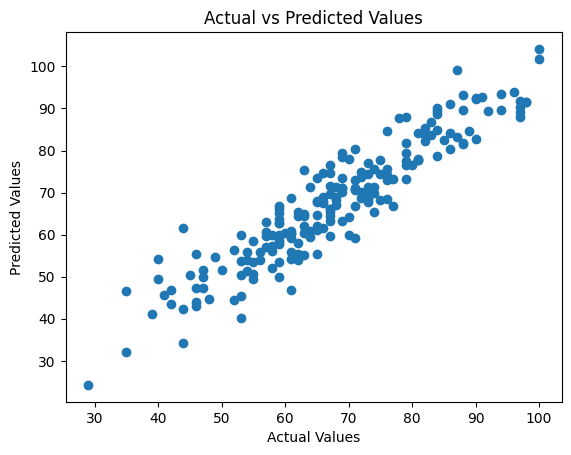

In [33]:
plt.scatter(y_test, pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

<Axes: xlabel='math_score'>

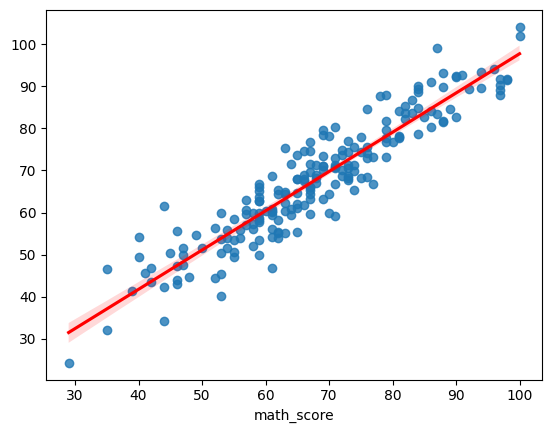

In [36]:
sns.regplot(x=y_test, y=pred, line_kws={"color":"red"})